In [1]:
from pathlib import Path
import math
import shutil
import sys
import tempfile

import duckdb
import yaml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pyfolio as pf
import vectorbtpro as vbt
import xgboost as xgb
from IPython.display import display

repo_root = Path.cwd().resolve()
if not (repo_root / "qts").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


START_DATE = pd.Timestamp("2018-01-01").date()
END_DATE = pd.Timestamp("2026-05-31").date()
BENCHMARK = "VN:VNINDEX"
INIT_CASH = 100_000_000
FEE_RATE = 0.0016

FORWARD_PERIOD = 21
CLASSIFICATION_WINDOW = 120
TRAIN_WINDOW = 504
REBALANCE_FREQUENCY = 10
MAX_POSITIONS = 5
MIN_FEATURE_COUNT = 3

CLASS_QUANTILES = [0.15, 0.45, 0.60, 0.85]
CLASS_SCORES = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
CLASS_PROB_COLS = [f"class_{i}_prob" for i in range(5)]
SIGNAL_PROB_COLS = ["class_3_prob", "class_4_prob"]
SIGNAL_PROB_SUM_COL = "class_3_4_prob"
SIGNAL_THRESHOLD = 0.40
FALLBACK_MIN_POSITIONS = 1
RANK_COL = "class_4_prob"

PREDICTOR_COLS = [
    "close_macd_histogram_50_200_30",
    "close_qsmom_21_252_126",
    "close_roc_0_63",
    "close_roc_0_252",
    "close_rsi_63",
    "close_fip_momentum_252",
    "close_volatility_annualized_252",
]
TARGET_COL = f"Return_fwd_{FORWARD_PERIOD}"

XGB_PARAMS = dict(
    n_estimators=20,
    learning_rate=0.1,
    max_depth=10,
    n_jobs=-1,
    random_state=123,
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
)

TEST_INTERVALS = [
    (pd.Timestamp("2021-01-01"), pd.Timestamp("2026-05-30")),
]
pd.Series(
    {
        "forward_period": FORWARD_PERIOD,
        "train_window": TRAIN_WINDOW,
        "classification_window": CLASSIFICATION_WINDOW,
        "rebalance_frequency": REBALANCE_FREQUENCY,
        "max_positions": MAX_POSITIONS,
        "signal_threshold": SIGNAL_THRESHOLD,
        "benchmark": BENCHMARK,
    },
    name="params",
).to_frame()

,params
forward_period,21
train_window,504
classification_window,120
rebalance_frequency,10
max_positions,5
signal_threshold,0.4
benchmark,VN:VNINDEX


In [2]:
# vn100 = yaml.safe_load((repo_root / "configs" / "assets" / "vn100.yml").read_text())
# symbols = vn100["symbols"]

# database_path = Path.home() / ".qts" / "database" / "qts.duckdb"
# db_copy_dir = Path(tempfile.mkdtemp(prefix="qts_ml_factor_"))
# db_copy_path = db_copy_dir / "qts.duckdb"
# shutil.copy2(database_path, db_copy_path)
# if database_path.with_suffix(".duckdb.wal").exists():
#     shutil.copy2(database_path.with_suffix(".duckdb.wal"), db_copy_path.with_suffix(".duckdb.wal"))

# placeholders = ", ".join("?" for _ in symbols)
# con = duckdb.connect(str(db_copy_path), read_only=True)
# raw = con.execute(
#     f"""
#     select date, symbol, open, high, low, close, volume
#     from vn_stock_prices
#     where symbol in ({placeholders}) and date between ? and ?
#     order by symbol, date
#     """,
#     [*symbols, START_DATE, END_DATE],
# ).pl()
# benchmark_raw = con.execute(
#     """
#     select date, symbol, open, high, low, close, volume
#     from vn_stock_prices
#     where symbol = ? and date between ? and ?
#     order by symbol, date
#     """,
#     [BENCHMARK, START_DATE, END_DATE],
# ).pl()
# con.close()
# pl.concat([raw, benchmark_raw], how="vertical").write_csv('../.qts_notebook_runtime/vn100/data.csv')

# pd.Series(
#     {
#         "symbols": len(symbols),
#         "rows": raw.height,
#         "start": raw["date"].min(),
#         "end": raw["date"].max(),
#         "benchmark": BENCHMARK,
#     },
#     name="loaded_data",
# ).to_frame()

In [3]:
data_csv_path = repo_root / ".qts_notebook_runtime" / "vn100" / "data.csv"
raw = pl.read_csv(data_csv_path, try_parse_dates=True)
asset_raw = raw.filter(pl.col("symbol") != BENCHMARK)
raw_prices = asset_raw.select(["date", "symbol", "close"]).to_pandas()
raw_prices["date"] = pd.to_datetime(raw_prices["date"])
raw_prices = raw_prices.drop_duplicates(["symbol", "date"], keep="last").sort_values(["symbol", "date"])


ohlcv_cols = ["open", "high", "low", "close", "volume"]
price_cols = ["open", "high", "low", "close"]

featured = (
    asset_raw.unique(subset=["symbol", "date"], keep="last")
    .sort(["symbol", "date"])
    .with_columns([pl.col(c).forward_fill().over("symbol").backward_fill().over("symbol").alias(c) for c in ohlcv_cols])
    .with_columns([pl.when(pl.col(c) <= 0).then(pl.lit(1e-10)).otherwise(pl.col(c)).alias(c) for c in ohlcv_cols])
    .with_columns(
        pl.max_horizontal([pl.col(c) for c in price_cols]).alias("high"),
        pl.min_horizontal([pl.col(c) for c in price_cols]).alias("low"),
    )
    .with_columns(
        pl.col("open").clip(pl.col("low"), pl.col("high")).alias("open"),
        pl.col("close").clip(pl.col("low"), pl.col("high")).alias("close"),
    )
    .filter(pl.len().over("symbol") >= 252)
)

featured = featured.with_columns(
    (pl.col("close") / pl.col("close").shift(21).over("symbol") - 1).alias("_qsmom_roc_fast"),
    (pl.col("close") / pl.col("close").shift(252).over("symbol") - 1).alias("_qsmom_roc_slow"),
    (pl.col("close") / pl.col("close").shift(126).over("symbol") - 1).alias("_qsmom_returns"),
).with_columns(
    pl.when(pl.col("_qsmom_roc_fast") > 0)
    .then(pl.col("_qsmom_roc_slow") + pl.col("_qsmom_returns"))
    .otherwise(pl.lit(None))
    .alias("close_qsmom_21_252_126")
)

featured = featured.with_columns(
    pl.col("close").ewm_mean(span=50, adjust=False, min_samples=50).over("symbol").alias("_ema_fast"),
    pl.col("close").ewm_mean(span=200, adjust=False, min_samples=200).over("symbol").alias("_ema_slow"),
).with_columns(
    (pl.col("_ema_fast") - pl.col("_ema_slow")).alias("_macd_line")
).with_columns(
    pl.col("_macd_line").ewm_mean(span=30, adjust=False, min_samples=30).over("symbol").alias("_macd_signal")
).with_columns(
    (pl.col("_macd_line") - pl.col("_macd_signal")).alias("close_macd_histogram_50_200_30")
)

rsi_delta = pl.col("close").diff().over("symbol")
rsi_gain = pl.when(rsi_delta > 0).then(rsi_delta).otherwise(0.0)
rsi_loss = pl.when(rsi_delta < 0).then(-rsi_delta).otherwise(0.0)
featured = featured.with_columns(
    (pl.col("close") / pl.col("close").shift(63).over("symbol") - 1).alias("close_roc_0_63"),
    (pl.col("close") / pl.col("close").shift(252).over("symbol") - 1).alias("close_roc_0_252"),
    (
        100
        - (
            100
            / (
                1
                + rsi_gain.ewm_mean(alpha=1 / 63, adjust=False, min_samples=63).over("symbol")
                / (rsi_loss.ewm_mean(alpha=1 / 63, adjust=False, min_samples=63).over("symbol") + 1e-8)
            )
        )
    ).alias("close_rsi_63"),
)

featured = featured.with_columns(
    (pl.col("close") / pl.col("close").shift(1).over("symbol") - 1).alias("_daily_return"),
    (pl.col("close") / pl.col("close").shift(252).over("symbol") - 1).alias("_total_return"),
).with_columns(
    (pl.col("_daily_return") > 0).cast(pl.Float64).rolling_sum(252, min_samples=252).over("symbol").alias("_positive_count"),
    (pl.col("_daily_return") < 0).cast(pl.Float64).rolling_sum(252, min_samples=252).over("symbol").alias("_negative_count"),
).with_columns(
    (pl.col("_total_return") * ((pl.col("_negative_count") - pl.col("_positive_count")) / 252)).alias("close_fip_momentum_252")
)

featured = featured.with_columns(
    (pl.col("close").log() - pl.col("close").shift(1).over("symbol").log()).alias("_log_return")
).with_columns(
    (pl.col("_log_return").rolling_std(252, min_samples=252).over("symbol") * math.sqrt(252)).alias("close_volatility_annualized_252"),
    (pl.col("close").shift(-FORWARD_PERIOD).over("symbol") / pl.col("close") - 1).alias(TARGET_COL),
)

model_frame = featured.select(["date", "symbol", TARGET_COL, *PREDICTOR_COLS]).to_pandas()
model_frame["date"] = pd.to_datetime(model_frame["date"])
model_frame = model_frame.replace([np.inf, -np.inf], np.nan).sort_values(["date", "symbol"]).reset_index(drop=True)
model_frame["feature_count"] = model_frame[PREDICTOR_COLS].notna().sum(axis=1)
model_frame.tail()

,date,symbol,Return_fwd_21,close_macd_histogram_50_200_30,close_qsmom_21_252_126,close_roc_0_63,close_roc_0_252,close_rsi_63,close_fip_momentum_252,close_volatility_annualized_252,feature_count
200569,2026-05-29,VN:VPB,NaN,0.037849,0.485718,-0.045640,0.519655,50.229936,-0.006186,0.406598,7
200570,2026-05-29,VN:VPI,NaN,0.507671,0.382631,0.040067,0.256048,53.939336,-0.008129,0.284154,7
200571,2026-05-29,VN:VRE,NaN,0.798473,0.272518,0.084034,0.264706,51.795768,-0.009454,0.500578,7
200572,2026-05-29,VN:VSC,NaN,-0.672048,NaN,-0.203187,0.114443,45.370196,0.005450,0.544201,6
200573,2026-05-29,VN:VTP,NaN,-0.598251,NaN,-0.171932,-0.197015,45.899272,-0.021109,0.399709,6


In [4]:
dataset_summary = pd.Series(
    {
        "rows": len(model_frame),
        "dates": model_frame["date"].nunique(),
        "symbols": model_frame["symbol"].nunique(),
        "feature_ready_rows": int((model_frame["feature_count"] >= MIN_FEATURE_COUNT).sum()),
        "training_ready_rows": int(((model_frame["feature_count"] >= MIN_FEATURE_COUNT) & model_frame[TARGET_COL].notna()).sum()),
    },
    name="training_data",
)
display(dataset_summary.to_frame())
model_frame[PREDICTOR_COLS + [TARGET_COL]].describe().T

,training_data
rows,200574
dates,2096
symbols,100
feature_ready_rows,177774
training_ready_rows,175674


,count,mean,std,min,25%,50%,75%,max
close_macd_histogram_50_200_30,177774.0,0.007182,0.878364,-13.865633,-0.269115,0.020161,0.310323,9.691864
close_qsmom_21_252_126,93991.0,0.577787,1.096036,-1.596737,-0.043950,0.300707,0.855396,10.597028
close_roc_0_63,194274.0,0.049950,0.229536,-0.776952,-0.081081,0.016551,0.146626,3.541842
close_roc_0_252,175374.0,0.263709,0.693080,-0.852629,-0.115646,0.094482,0.414448,8.259965
close_rsi_63,194374.0,51.241400,6.567710,20.121014,46.952785,50.764929,55.088286,87.133990
close_fip_momentum_252,175374.0,-0.031982,0.090428,-2.018561,-0.029410,-0.006731,0.000143,0.209927
close_volatility_annualized_252,175374.0,0.364485,0.109953,0.059214,0.285802,0.354332,0.431136,1.369501
Return_fwd_21,198474.0,0.016321,0.123221,-0.730942,-0.048888,0.006637,0.073239,2.741806


In [5]:
all_dates = pd.DatetimeIndex(model_frame["date"].drop_duplicates()).sort_values()
rebalance_dates = all_dates[::REBALANCE_FREQUENCY]
rebalance_dates = pd.DatetimeIndex(
    [d for d in rebalance_dates if any(start <= d <= end for start, end in TEST_INTERVALS)]
)
date_position = pd.Series(range(len(all_dates)), index=all_dates)

prediction_rows = []
for rebalance_date in rebalance_dates:
    latest_trainable_idx = int(date_position.loc[rebalance_date]) - FORWARD_PERIOD
    trainable_dates = all_dates[: latest_trainable_idx + 1]
    trainable_dates = pd.DatetimeIndex(
        [d for d in trainable_dates if not any(start <= d <= end for start, end in TEST_INTERVALS)]
    )
    if len(trainable_dates) < max(TRAIN_WINDOW, CLASSIFICATION_WINDOW):
        continue

    train_dates = trainable_dates[-TRAIN_WINDOW:]
    threshold_dates = trainable_dates[-CLASSIFICATION_WINDOW:]

    train = model_frame[model_frame["date"].isin(train_dates)].copy()
    train = train[(train[TARGET_COL].notna()) & (train["feature_count"] >= MIN_FEATURE_COUNT)]

    threshold_frame = train[train["date"].isin(threshold_dates)]
    predict = model_frame[(model_frame["date"] == rebalance_date) & (model_frame["feature_count"] >= MIN_FEATURE_COUNT)].copy()
    if len(train) == 0 or len(threshold_frame) == 0 or len(predict) == 0:
        continue

    thresholds = np.quantile(threshold_frame[TARGET_COL], CLASS_QUANTILES)
    train_labels = np.searchsorted(thresholds, train[TARGET_COL], side="left")
    classes = np.array(sorted(np.unique(train_labels)), dtype=int)

    model = xgb.XGBClassifier(**XGB_PARAMS, num_class=len(classes))
    model.fit(train[PREDICTOR_COLS], np.searchsorted(classes, train_labels))
    raw_probabilities = model.predict_proba(predict[PREDICTOR_COLS])
    probabilities = np.zeros((len(predict), 5))
    for source_idx, class_label in enumerate(classes):
        probabilities[:, class_label] = raw_probabilities[:, source_idx]
    probabilities = probabilities / probabilities.sum(axis=1, keepdims=True)

    target_values = predict[TARGET_COL].to_numpy(dtype=float)
    realized_class = np.full(len(predict), np.nan)
    finite_target = np.isfinite(target_values)
    realized_class[finite_target] = np.searchsorted(thresholds, target_values[finite_target], side="left")

    out = predict[["date", "symbol", TARGET_COL]].rename(columns={TARGET_COL: "realized_forward_return"}).copy()
    out["predicted_class"] = probabilities.argmax(axis=1)
    out["realized_class"] = realized_class
    out["score"] = probabilities @ CLASS_SCORES
    for col_idx, col_name in enumerate(CLASS_PROB_COLS):
        out[col_name] = probabilities[:, col_idx]
    out[SIGNAL_PROB_SUM_COL] = out[SIGNAL_PROB_COLS].sum(axis=1)
    prediction_rows.append(out)

predictions = pd.concat(prediction_rows, ignore_index=True)
predictions = predictions.sort_values(["date", RANK_COL, "symbol"], ascending=[True, False, True])

selected_predictions = []
for prediction_date, cross_section in predictions.groupby("date", sort=True):
    selected = cross_section[cross_section[SIGNAL_PROB_SUM_COL] > SIGNAL_THRESHOLD].copy()
    if len(selected) < FALLBACK_MIN_POSITIONS:
        fallback = (
            cross_section[~cross_section["symbol"].isin(selected["symbol"])]
            .sort_values([RANK_COL, "symbol"], ascending=[False, True])
            .head(FALLBACK_MIN_POSITIONS - len(selected))
        )
        selected = pd.concat([selected, fallback], ignore_index=True)
    selected = selected.sort_values([RANK_COL, "symbol"], ascending=[False, True]).head(MAX_POSITIONS)
    selected["target_weight"] = 1 / MAX_POSITIONS
    selected_predictions.append(selected)

selected_predictions = pd.concat(selected_predictions, ignore_index=True)

scored_predictions = predictions[predictions["realized_forward_return"].notna()].copy()
selected_eval = []

for prediction_date, cross_section in scored_predictions.groupby("date", sort=True):
    selected = cross_section[cross_section[SIGNAL_PROB_SUM_COL] > SIGNAL_THRESHOLD].copy()
    if len(selected) < FALLBACK_MIN_POSITIONS:
        fallback = (
            cross_section[~cross_section["symbol"].isin(selected["symbol"])]
            .sort_values([RANK_COL, "symbol"], ascending=[False, True])
            .head(FALLBACK_MIN_POSITIONS - len(selected))
        )
        selected = pd.concat([selected, fallback], ignore_index=True)
    selected_eval.append(selected.sort_values([RANK_COL, "symbol"], ascending=[False, True]).head(MAX_POSITIONS))
selected_eval = pd.concat(selected_eval, ignore_index=True)

class_eval = scored_predictions[scored_predictions["realized_class"].notna()]
run_eval = pd.Series(
    {
        "prediction_rows": len(scored_predictions),
        "prediction_dates": scored_predictions["date"].nunique(),
        "selected_rows": len(selected_eval),
        "selected_dates": selected_eval["date"].nunique(),
        "top_mean_forward_return": selected_eval["realized_forward_return"].mean(),
        "class_accuracy": (class_eval["predicted_class"] == class_eval["realized_class"].astype(int)).mean(),
    },
    name="notebook",
)


In [6]:
close = raw_prices.pivot(index="date", columns="symbol", values="close").sort_index().sort_index(axis=1)
target_weights = pd.DataFrame(np.nan, index=close.index, columns=close.columns)
next_session = dict(zip(close.index[:-1], close.index[1:], strict=False))
previous_symbols = set()

for prediction_date, selected in selected_predictions.groupby("date", sort=True):
    execution_date = next_session.get(pd.Timestamp(prediction_date))
    if execution_date is None:
        continue

    current_symbols = set(selected["symbol"])
    target_weights.loc[execution_date, sorted(previous_symbols - current_symbols)] = 0.0
    target_weights.loc[execution_date, sorted(current_symbols - previous_symbols)] = 1 / MAX_POSITIONS
    previous_symbols = current_symbols

used_symbols = target_weights.notna().any(axis=0)
close_bt = close.loc[:, used_symbols]
weights_bt = target_weights.loc[:, used_symbols]

pd.Series(
    {
        "backtest_symbols": int(used_symbols.sum()),
        "order_dates": int(weights_bt.notna().any(axis=1).sum()),
        "first_order_date": weights_bt.dropna(how="all").index.min().date(),
        "last_order_date": weights_bt.dropna(how="all").index.max().date(),
    },
    name="orders",
).to_frame()

,orders
backtest_symbols,87
order_dates,131
first_order_date,2021-01-15
last_order_date,2026-05-25


In [7]:
last_order_date = weights_bt.last_valid_index()
last_order = weights_bt.loc[last_order_date].dropna().rename("weight").to_frame()

print("Last order date:", last_order_date)
print(last_order)

Last order date: 2026-05-25 00:00:00
        weight
symbol        
VN:DGC     0.2
VN:GAS     0.0
VN:HDG     0.2
VN:PC1     0.0
VN:PLX     0.0
VN:VIX     0.2


,value
Start Index,2018-01-02 00:00:00
End Index,2026-05-29 00:00:00
Total Duration,2096 days 00:00:00
Start Value,100000000.0
Min Value,83141184.970866
Max Value,582614098.441981
End Value,544085558.119356
Total Return [%],444.085558
Benchmark Return [%],233.630756
Position Coverage [%],63.692748


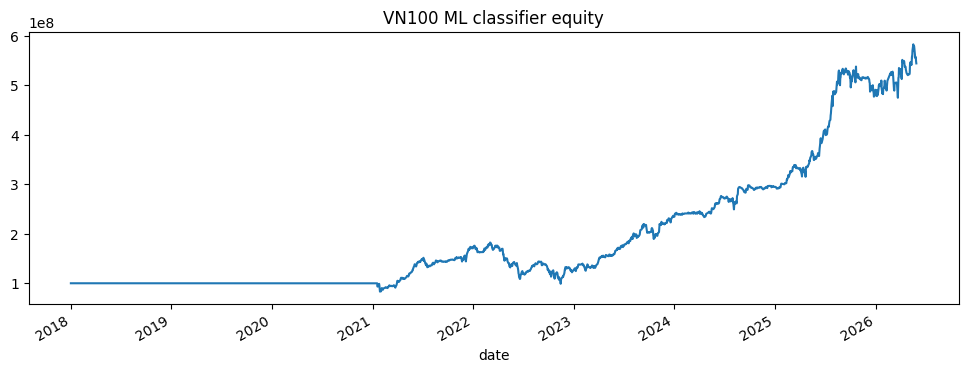

In [8]:
portfolio = vbt.Portfolio.from_orders(
    close=close_bt,
    size=weights_bt,
    size_type="TargetPercent",
    fees=FEE_RATE,
    cash_sharing=True,
    group_by=True,
    init_cash=INIT_CASH,
    freq=pd.tseries.frequencies.to_offset(close_bt.index[1] - close_bt.index[0]),
)

equity = portfolio.get_value(group_by=True).rename("equity")
returns = portfolio.get_returns(group_by=True).astype(float).rename("portfolio_return")

returns_list = returns.to_list()
equity_list = equity.to_list()
returns_std = np.std(returns_list, ddof=1)
downside = [value for value in returns_list if value < 0]
downside_std = np.std(downside, ddof=1)
running_peak = np.maximum.accumulate(equity_list)
qts_metrics = pd.Series(
    {
        "sharpe": np.mean(returns_list) / returns_std * np.sqrt(252),
        "sortino": np.mean(returns_list) / downside_std * np.sqrt(252),
        "cagr": (equity_list[-1] / equity_list[0]) ** (252 / (len(equity_list) - 1)) - 1,
        "max_drawdown": abs(np.min((np.array(equity_list) - running_peak) / running_peak)),
        "win_rate": np.mean(np.array(returns_list) > 0),
    },
    name="notebook",
)


portfolio_stats = portfolio.stats()
display(portfolio_stats.to_frame("value") if isinstance(portfolio_stats, pd.Series) else portfolio_stats)

equity.plot(figsize=(12, 4), title="VN100 ML classifier equity")
plt.show()

,value
Annual return,0.373845
Cumulative returns,4.440856
Annual volatility,0.241808
Sharpe ratio,1.435698
Calmar ratio,0.817832
Stability,0.888118
Max drawdown,-0.457117
Omega ratio,1.309523
Sortino ratio,2.050292
Skew,-0.526684


/Users/s2997726/Desktop/code/quant/QS/QTradeSystematic/.venv/lib/python3.13/site-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '37.384%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2021-01-04
End date,2026-05-29
Total months,64
,Backtest
Annual return,37.384%
Cumulative returns,444.086%
Annual volatility,24.181%
Sharpe ratio,1.44
Calmar ratio,0.82
Stability,0.89
Max drawdown,-45.712%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,45.71,2022-03-04,2022-11-15,2023-07-17,357
1,16.86,2021-01-14,2021-01-28,2021-03-31,55
2,13.74,2023-09-12,2023-10-19,2023-11-09,43
3,12.64,2021-07-05,2021-07-19,2021-11-02,87
4,11.72,2025-10-22,2026-03-23,2026-04-08,121


/Users/s2997726/Desktop/code/quant/QS/QTradeSystematic/.venv/lib/python3.13/site-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


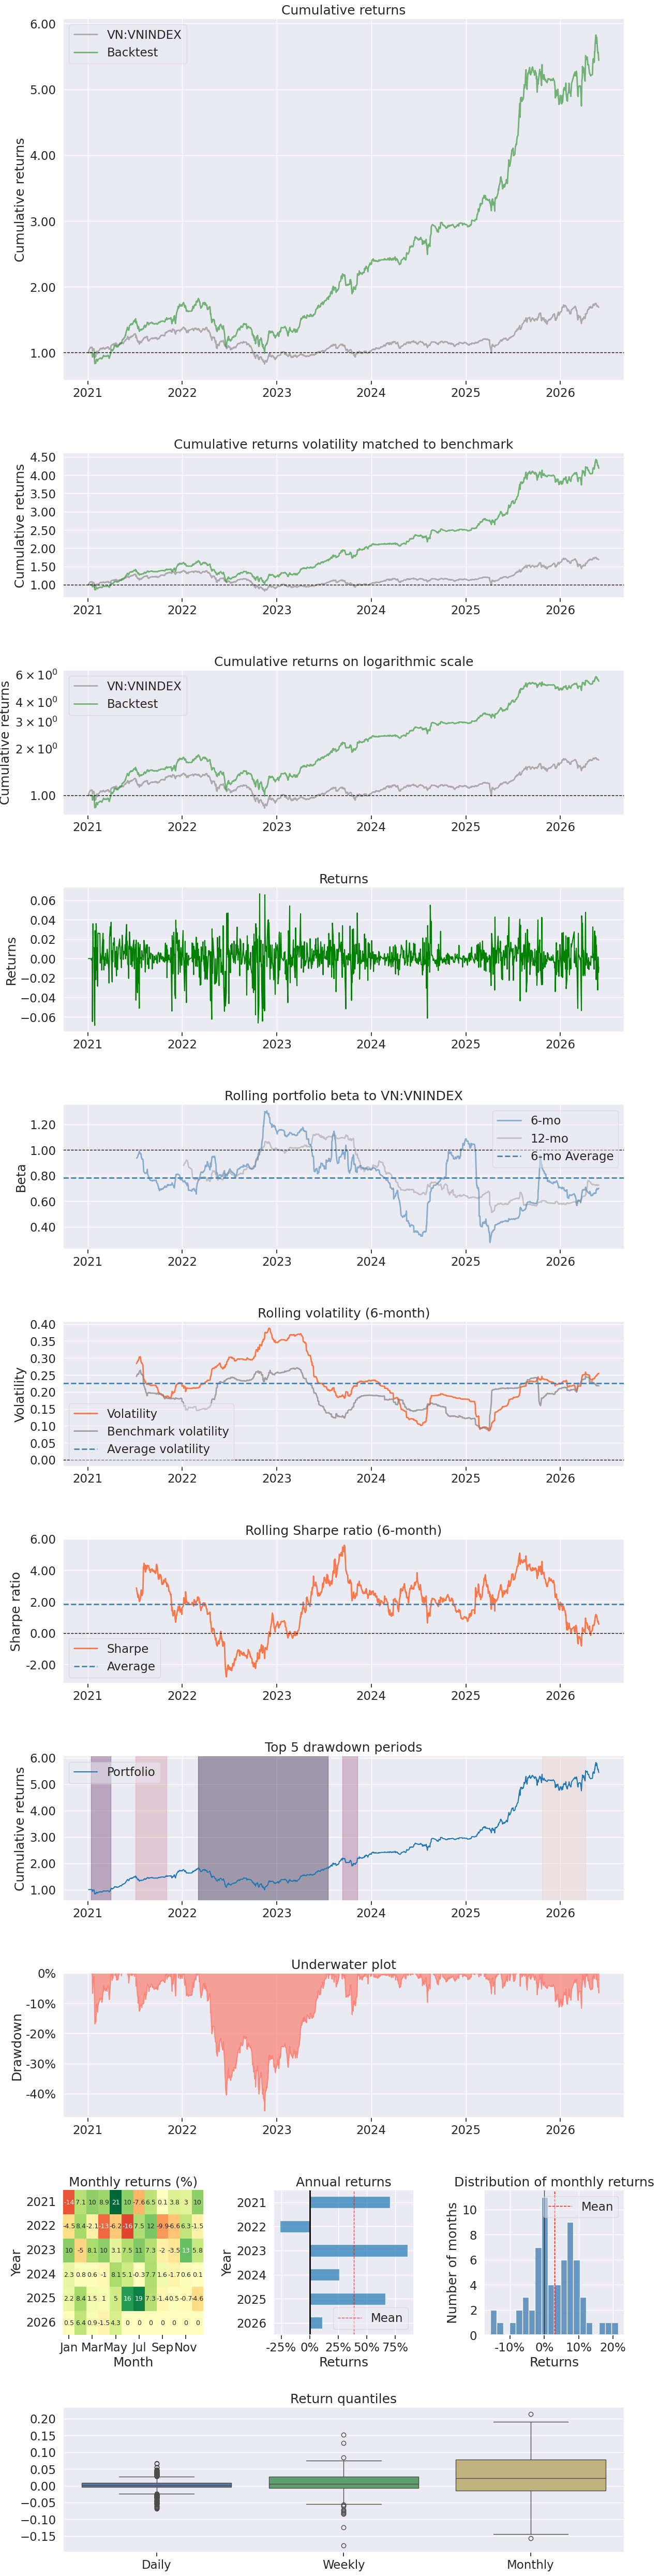

In [10]:
pyfolio_returns = returns.replace([np.inf, -np.inf], np.nan).dropna()
pyfolio_returns.index = pd.to_datetime(pyfolio_returns.index, utc=True).normalize()
test_start = pd.Timestamp(TEST_INTERVALS[0][0], tz="UTC")
test_end = pd.Timestamp(TEST_INTERVALS[-1][1], tz="UTC")
pyfolio_returns = pyfolio_returns.loc[test_start:test_end]
pyfolio_returns.name = "ml_factor_classifier"
data_csv_path = repo_root / ".qts_notebook_runtime" / "vn100" / "data.csv"
ohlcv_columns = ["date", "symbol", "open", "high", "low", "close", "volume"]

benchmark = (
    raw.filter(pl.col("symbol") == BENCHMARK)
    .select(["date", "close"])
    .unique(subset=["date"], keep="last")
    .sort("date")
    .to_pandas()
)
if benchmark.empty:
    database_path = Path.home() / ".qts" / "database" / "qts.duckdb"
    con = duckdb.connect(str(database_path), read_only=True)
    benchmark_raw = con.execute(
        """
        select date, symbol, open, high, low, close, volume
        from vn_stock_prices
        where symbol = ? and date between ? and ?
        order by symbol, date
        """,
        [BENCHMARK, START_DATE, END_DATE],
    ).pl()
    con.close()
    if benchmark_raw.is_empty():
        raise ValueError(f"{BENCHMARK} is not present in {database_path}.")
    raw = (
        pl.concat([raw.select(ohlcv_columns), benchmark_raw.select(ohlcv_columns)], how="vertical")
        .unique(subset=["symbol", "date"], keep="last")
        .sort(["symbol", "date"])
    )
    raw.write_csv(data_csv_path)
    benchmark = (
        raw.filter(pl.col("symbol") == BENCHMARK)
        .select(["date", "close"])
        .unique(subset=["date"], keep="last")
        .sort("date")
        .to_pandas()
    )

benchmark["date"] = pd.to_datetime(benchmark["date"], utc=True).dt.normalize()
benchmark_returns = (
    benchmark.set_index("date")["close"]
    .pct_change()
    .loc[test_start:test_end]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .rename(BENCHMARK)
)
aligned_returns = pd.concat([pyfolio_returns, benchmark_returns], axis=1, join="inner").dropna()
if aligned_returns.empty:
    raise ValueError(f"No {BENCHMARK} returns overlap pyfolio_returns between {test_start.date()} and {test_end.date()}.")
pyfolio_returns = aligned_returns["ml_factor_classifier"]
benchmark_returns = aligned_returns[BENCHMARK]

pyfolio_stats = pf.timeseries.perf_stats(pyfolio_returns, factor_returns=benchmark_returns)
display(pyfolio_stats.to_frame("value"))

pf.create_returns_tear_sheet(pyfolio_returns, benchmark_rets=benchmark_returns)